# Behavioural Features Clustering with PCA

## RQ3(I): Do prompt-engineered personas reliably induce distinct behavioural phenotypes within each model, and does a sham persona fail to induce distinct clusters (negative control)?

**An unsupervised clustering analysis of the AI agents' observable gameplay actions, focusing on raw performance metrics like deck preferences and final scores**

Purpose of this notebook is to perform behavioural space clustering for Gemini and Deepseek personalities using 3 clustering algorithms; K-Means, Gaussian Mixture Models (GMM) and Agglomerative clustering. The clusters would represent distinct behavioral strategies based on deck preferences, learning dynamics, and risk/loss responses. Moreover, we use the Silhouette score and the Adjutsed Rand Index (ARI) to measure the quality of the clusters and carry out statistical tests to measure the association between personas and clusters.

### Data Imports and Checks

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score, silhouette_samples
from scipy.stats import chi2_contingency

In [2]:
gemini_game = pd.read_csv("../data/iowa_models/gemini/gemini_igt_persona_combined.csv")
deepseek_game = pd.read_csv("../data/iowa_models/deepseek/deepseek_igt_persona_combined.csv")

gemini_game["dataset"] = "Gemini"
deepseek_game["dataset"] = "DeepSeek"

print("Gemini gameplay shape:", gemini_game.shape)
print("DeepSeek gameplay shape:", deepseek_game.shape)

print("\nGemini columns:", gemini_game.columns.tolist())
print("DeepSeek columns:", deepseek_game.columns.tolist())

gemini_game.head()

Gemini gameplay shape: (35000, 9)
DeepSeek gameplay shape: (35000, 9)

Gemini columns: ['session_id', 'persona', 'trial_number', 'choice', 'won', 'loss', 'total', 'model', 'dataset']
DeepSeek columns: ['session_id', 'persona', 'trial_number', 'choice', 'won', 'loss', 'total', 'model', 'dataset']


,session_id,persona,trial_number,choice,won,loss,total,model,dataset
0,1,baseline,1,Q,100,0,2100,gemini,Gemini
1,1,baseline,2,K,100,-1250,950,gemini,Gemini
2,1,baseline,3,S,50,-50,950,gemini,Gemini
3,1,baseline,4,D,50,0,1000,gemini,Gemini
4,1,baseline,5,D,50,0,1050,gemini,Gemini


In [3]:
# Check the number of trials
for name, g in [("Gemini", gemini_game), ("DeepSeek", deepseek_game)]:
    counts = g.groupby(["persona", "session_id"])["trial_number"].count()
    print("\n", "="*70)
    print(name, "trial counts per (persona, session_id):")
    print(counts.describe())
    print("Any != 100?", (counts != 100).sum())


Gemini trial counts per (persona, session_id):
count    350.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
Name: trial_number, dtype: float64
Any != 100? 0

DeepSeek trial counts per (persona, session_id):
count    350.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
Name: trial_number, dtype: float64
Any != 100? 0


In [4]:
game = pd.concat([gemini_game, deepseek_game], ignore_index=True)

# Create a unique participant id to avoid session_id collisions across models/personas
game["participant"] = (
    game["dataset"].astype(str) + "_" +
    game["persona"].astype(str) + "_" +
    game["session_id"].astype(str)
)

game = game.sort_values(["participant", "trial_number"]).reset_index(drop=True)

print("Combined gameplay rows:", game.shape[0])
print("Unique sessions:", game["participant"].nunique())
game.head()

Combined gameplay rows: 70000
Unique sessions: 700


,session_id,persona,trial_number,choice,won,loss,total,model,dataset,participant
0,1,baseline,1,Q,100,0,2100,deepseek,DeepSeek,DeepSeek_baseline_1
1,1,baseline,2,Q,100,-250,1950,deepseek,DeepSeek,DeepSeek_baseline_1
2,1,baseline,3,K,100,-1250,800,deepseek,DeepSeek,DeepSeek_baseline_1
3,1,baseline,4,D,50,0,850,deepseek,DeepSeek,DeepSeek_baseline_1
4,1,baseline,5,Q,100,-250,700,deepseek,DeepSeek,DeepSeek_baseline_1


### Step 1: Extract behavioural features per session

In [5]:
records = []

for (participant, dataset, persona), grp in game.groupby(["participant", "dataset", "persona"]):
    grp = grp.sort_values("trial_number").head(100)

    if len(grp) < 50:
        continue

    choices = grp["choice"].astype(str).str.strip().str.upper().values
    n = len(choices)

    deck_Q = (choices == "Q").mean()
    deck_K = (choices == "K").mean()
    deck_S = (choices == "S").mean()
    deck_D = (choices == "D").mean()

    # advantageous - disadvantageous
    net_score = (deck_S + deck_D) - (deck_Q + deck_K)

    # learning slope: change in (S or D) rate from first 50 to last 50
    early_good = ((choices[:50] == "S") | (choices[:50] == "D")).mean()
    late_good  = ((choices[50:] == "S") | (choices[50:] == "D")).mean()
    learning_slope = late_good - early_good

    # risk seeking: Q+K
    risk_seeking = deck_Q + deck_K

    # loss sensitivity: switch after a loss
    losses = grp["loss"].astype(float).values
    loss_idx = np.where(losses < 0)[0]
    switches = 0
    for i in loss_idx:
        if i + 1 < n and choices[i + 1] != choices[i]:
            switches += 1
    loss_sensitivity = switches / max(len(loss_idx), 1)

    final_total = grp["total"].astype(float).iloc[-1]

    records.append({
        "participant": participant,
        "dataset": dataset,
        "persona": persona,
        "deck_Q_pct": deck_Q,
        "deck_K_pct": deck_K,
        "deck_S_pct": deck_S,
        "deck_D_pct": deck_D,
        "net_score": net_score,
        "learning_slope": learning_slope,
        "risk_seeking": risk_seeking,
        "loss_sensitivity": loss_sensitivity,
        "final_total": final_total
    })

feature_df = pd.DataFrame(records)
print("Feature df shape:", feature_df.shape)
feature_df.head()

Feature df shape: (700, 12)


,participant,dataset,persona,deck_Q_pct,deck_K_pct,deck_S_pct,deck_D_pct,net_score,learning_slope,risk_seeking,loss_sensitivity,final_total
0,DeepSeek_baseline_1,DeepSeek,baseline,0.09,0.10,0.00,0.81,0.62,0.02,0.19,0.555556,4700.0
1,DeepSeek_baseline_10,DeepSeek,baseline,0.04,0.57,0.32,0.07,-0.22,-0.54,0.61,0.307692,2350.0
2,DeepSeek_baseline_11,DeepSeek,baseline,0.09,0.28,0.63,0.00,0.26,0.02,0.37,0.317073,1200.0
3,DeepSeek_baseline_12,DeepSeek,baseline,0.05,0.00,0.16,0.79,0.90,0.02,0.05,0.647059,5000.0
4,DeepSeek_baseline_13,DeepSeek,baseline,0.07,0.27,0.60,0.06,0.32,-0.32,0.34,0.483871,3750.0


In [6]:
print("Feature summary stats:")
feature_df.describe().round(3)

Feature summary stats:


,deck_Q_pct,deck_K_pct,deck_S_pct,deck_D_pct,net_score,learning_slope,risk_seeking,loss_sensitivity,final_total
count,700.000,700.000,700.000,700.000,700.000,700.000,700.000,700.000,700.000
mean,0.221,0.207,0.301,0.271,0.144,0.108,0.428,0.500,2291.000
std,0.307,0.189,0.233,0.253,0.585,0.208,0.293,0.341,2019.897
min,0.000,0.000,0.000,0.000,-1.000,-0.640,0.000,0.000,-4750.000
25%,0.030,0.050,0.090,0.020,0.000,0.000,0.170,0.250,1087.500
50%,0.090,0.210,0.270,0.240,0.100,0.040,0.450,0.429,2650.000
75%,0.250,0.250,0.450,0.380,0.660,0.200,0.500,0.877,3750.000
max,1.000,1.000,0.920,0.970,1.000,0.860,1.000,1.000,8750.000


### Step 2: Shared clustering setup

We use the same behavioural features for all analyses.  
To improve identifiability, we drop one deck proportion (`deck_D_pct`) because the four deck percentages sum to 1.

In [7]:
feature_cols = [
    "deck_Q_pct",
    "deck_K_pct",
    "deck_S_pct",
    # drop deck_D_pct because deck proportions are compositional and sum to 1
    "net_score",
    "learning_slope",
    "risk_seeking",
    "loss_sensitivity",
    "final_total"
]

print("Features used:", feature_cols)
print("Number of sessions:", len(feature_df))
feature_df[feature_cols].describe().round(3)

Features used: ['deck_Q_pct', 'deck_K_pct', 'deck_S_pct', 'net_score', 'learning_slope', 'risk_seeking', 'loss_sensitivity', 'final_total']
Number of sessions: 700


,deck_Q_pct,deck_K_pct,deck_S_pct,net_score,learning_slope,risk_seeking,loss_sensitivity,final_total
count,700.000,700.000,700.000,700.000,700.000,700.000,700.000,700.000
mean,0.221,0.207,0.301,0.144,0.108,0.428,0.500,2291.000
std,0.307,0.189,0.233,0.585,0.208,0.293,0.341,2019.897
min,0.000,0.000,0.000,-1.000,-0.640,0.000,0.000,-4750.000
25%,0.030,0.050,0.090,0.000,0.000,0.170,0.250,1087.500
50%,0.090,0.210,0.270,0.100,0.040,0.450,0.429,2650.000
75%,0.250,0.250,0.450,0.660,0.200,0.500,0.877,3750.000
max,1.000,1.000,0.920,1.000,0.860,1.000,1.000,8750.000


### Step 3: create the combined standardized dataset first

In [8]:
combined_df = feature_df.copy()

X_combined = combined_df[feature_cols].to_numpy()

combined_scaler = StandardScaler()
X_combined_scaled = combined_scaler.fit_transform(X_combined)

print("Combined standardized matrix shape:", X_combined_scaled.shape)

Combined standardized matrix shape: (700, 8)


### Step 4: choose one shared k from the combined data

We pick a single shared number of clusters from the combined standardized dataset, then use that same `k` for Gemini, DeepSeek, and the combined dataset.

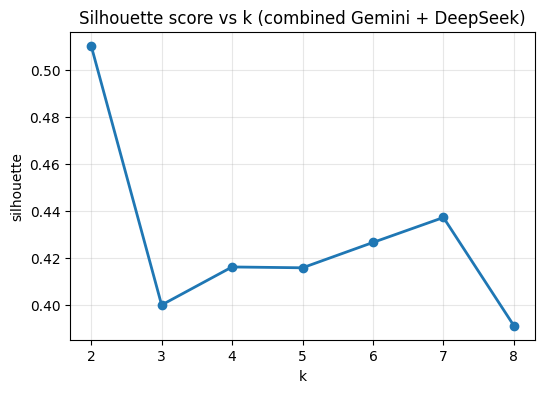

,k,silhouette
0,2,0.5104
1,3,0.4001
2,4,0.4163
3,5,0.4159
4,6,0.4267
5,7,0.4373
6,8,0.3913


Shared k chosen from combined data: 2


In [9]:
def silhouette_curve(X_scaled, k_min=2, k_max=8):
    ks = list(range(k_min, k_max + 1))
    scores = []
    for k in ks:
        km = KMeans(n_clusters=k, random_state=42, n_init=50)
        labels = km.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        scores.append(score)
    return ks, scores

ks, scores = silhouette_curve(X_combined_scaled, 2, 8)

plt.figure(figsize=(6, 4))
plt.plot(ks, scores, "o-", linewidth=2)
plt.title("Silhouette score vs k (combined Gemini + DeepSeek)")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.grid(True, alpha=0.3)
plt.show()

silhouette_table = pd.DataFrame({"k": ks, "silhouette": scores})
display(silhouette_table.round(4))

k_shared = ks[int(np.argmax(scores))]
print("Shared k chosen from combined data:", k_shared)

### Step 5: use that same shared k for Gemini and DeepSeek separately

In [10]:
def fit_methods_for_subset(sub_df, feature_cols, k_shared):
    sub_df = sub_df.copy()
    X = sub_df[feature_cols].to_numpy()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # K-means
    km = KMeans(n_clusters=k_shared, random_state=42, n_init=50)
    sub_df["kmeans_cluster"] = km.fit_predict(X_scaled)

    # Gaussian Mixture Model
    gmm = GaussianMixture(n_components=k_shared, random_state=42)
    sub_df["gmm_cluster"] = gmm.fit_predict(X_scaled)

    # Agglomerative clustering
    agg = AgglomerativeClustering(n_clusters=k_shared, linkage="ward")
    sub_df["agg_cluster"] = agg.fit_predict(X_scaled)

    # PCA for 2D visualisation inside this subset
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X_scaled)
    sub_df["pca_x"] = coords[:, 0]
    sub_df["pca_y"] = coords[:, 1]

    metrics = {
        "n_sessions": len(sub_df),
        "pca_var_2d": pca.explained_variance_ratio_.sum(),
        "silhouette_kmeans": silhouette_score(X_scaled, sub_df["kmeans_cluster"]),
        "silhouette_gmm": silhouette_score(X_scaled, sub_df["gmm_cluster"]),
        "silhouette_agg": silhouette_score(X_scaled, sub_df["agg_cluster"]),
        "ari_kmeans_vs_gmm": adjusted_rand_score(sub_df["kmeans_cluster"], sub_df["gmm_cluster"]),
        "ari_kmeans_vs_agg": adjusted_rand_score(sub_df["kmeans_cluster"], sub_df["agg_cluster"]),
        "ari_gmm_vs_agg": adjusted_rand_score(sub_df["gmm_cluster"], sub_df["agg_cluster"]),

        # ARI comparing against ground truth persons
        "ari_persona_vs_kmeans": adjusted_rand_score(sub_df["persona"], sub_df["kmeans_cluster"]),
        "ari_persona_vs_gmm": adjusted_rand_score(sub_df["persona"], sub_df["gmm_cluster"]),
        "ari_persona_vs_agg": adjusted_rand_score(sub_df["persona"], sub_df["agg_cluster"]),
    }

    return sub_df, X_scaled, metrics

gemini_df, X_gemini_scaled, gemini_metrics = fit_methods_for_subset(
    feature_df[feature_df["dataset"] == "Gemini"], feature_cols, k_shared
)

deepseek_df, X_deepseek_scaled, deepseek_metrics = fit_methods_for_subset(
    feature_df[feature_df["dataset"] == "DeepSeek"], feature_cols, k_shared
)

combined_results_df, X_combined_scaled, combined_metrics = fit_methods_for_subset(
    feature_df, feature_cols, k_shared
)

metrics_df = pd.DataFrame(
    [gemini_metrics, deepseek_metrics, combined_metrics],
    index=["Gemini", "DeepSeek", "Combined"]
)
display(metrics_df.round(4))

,n_sessions,pca_var_2d,silhouette_kmeans,silhouette_gmm,silhouette_agg,ari_kmeans_vs_gmm,ari_kmeans_vs_agg,ari_gmm_vs_agg,ari_persona_vs_kmeans,ari_persona_vs_gmm,ari_persona_vs_agg
Gemini,350,0.6835,0.5309,0.4050,0.5309,0.1493,1.0000,0.1493,0.0799,0.2724,0.0799
DeepSeek,350,0.6258,0.5070,0.5080,0.5082,0.9689,0.9205,0.9205,0.0919,0.0965,0.0760
Combined,700,0.6417,0.5104,0.5105,0.5096,0.9535,0.9440,0.9136,0.0907,0.1018,0.0786


### Step 6: Combined dataset with the same shared k

We also cluster the full combined dataset using the same `k_shared`.

In [11]:
# keep a clean combined results table
combined_df = combined_results_df.copy()

print("Combined cluster counts")
print("\nK-means")
print(combined_df["kmeans_cluster"].value_counts().sort_index())

print("\nGMM")
print(combined_df["gmm_cluster"].value_counts().sort_index())

print("\nAgglomerative")
print(combined_df["agg_cluster"].value_counts().sort_index())

Combined cluster counts

K-means
kmeans_cluster
0    604
1     96
Name: count, dtype: int64

GMM
gmm_cluster
0    600
1    100
Name: count, dtype: int64

Agglomerative
agg_cluster
0    611
1     89
Name: count, dtype: int64


### Step 7: Robustness check across three clustering methods

We compare K-means, Gaussian Mixture Models, and Agglomerative clustering using silhouette and pairwise agreement (Adjusted Rand Index).

In [12]:
print("Pairwise agreement on combined dataset")
print("K-means vs GMM ARI:", round(adjusted_rand_score(combined_df["kmeans_cluster"], combined_df["gmm_cluster"]), 4))
print("K-means vs Agglomerative ARI:", round(adjusted_rand_score(combined_df["kmeans_cluster"], combined_df["agg_cluster"]), 4))
print("GMM vs Agglomerative ARI:", round(adjusted_rand_score(combined_df["gmm_cluster"], combined_df["agg_cluster"]), 4))

print("\nCross-tab: K-means vs GMM")
display(pd.crosstab(combined_df["kmeans_cluster"], combined_df["gmm_cluster"]))

print("\nCross-tab: K-means vs Agglomerative")
display(pd.crosstab(combined_df["kmeans_cluster"], combined_df["agg_cluster"]))

print("\nCross-tab: GMM vs Agglomerative")
display(pd.crosstab(combined_df["gmm_cluster"], combined_df["agg_cluster"]))

Pairwise agreement on combined dataset
K-means vs GMM ARI: 0.9535
K-means vs Agglomerative ARI: 0.944
GMM vs Agglomerative ARI: 0.9136

Cross-tab: K-means vs GMM


gmm_cluster,0,1
kmeans_cluster,,
0,599,5
1,1,95



Cross-tab: K-means vs Agglomerative


agg_cluster,0,1
kmeans_cluster,,
0,604,0
1,7,89



Cross-tab: GMM vs Agglomerative


agg_cluster,0,1
gmm_cluster,,
0,600,0
1,11,89


### Step 8: add feature summaries for both methods

Below are feature summaries for all three clustering methods on the combined dataset, followed by Gemini and DeepSeek separately.

In [13]:
def show_feature_summaries(df, label_col, feature_cols, title):
    print("\n" + "=" * 90)
    print(title)
    summary = df.groupby(label_col)[feature_cols].mean().round(3)
    display(summary)

for label_col, title in [
    ("kmeans_cluster", "Combined: K-means feature summary"),
    ("gmm_cluster", "Combined: GMM feature summary"),
    ("agg_cluster", "Combined: Agglomerative feature summary"),
]:
    show_feature_summaries(combined_df, label_col, feature_cols, title)

for dataset_name, sub in [("Gemini", gemini_df), ("DeepSeek", deepseek_df)]:
    for label_col, method_name in [
        ("kmeans_cluster", "K-means"),
        ("gmm_cluster", "GMM"),
        ("agg_cluster", "Agglomerative"),
    ]:
        show_feature_summaries(sub, label_col, feature_cols, f"{dataset_name}: {method_name} feature summary")


Combined: K-means feature summary


,deck_Q_pct,deck_K_pct,deck_S_pct,net_score,learning_slope,risk_seeking,loss_sensitivity,final_total
kmeans_cluster,,,,,,,,
0,0.110,0.228,0.348,0.324,0.126,0.338,0.576,2733.940
1,0.921,0.073,0.006,-0.987,-0.008,0.994,0.021,-495.833



Combined: GMM feature summary


,deck_Q_pct,deck_K_pct,deck_S_pct,net_score,learning_slope,risk_seeking,loss_sensitivity,final_total
gmm_cluster,,,,,,,,
0,0.111,0.222,0.350,0.333,0.128,0.334,0.580,2723.0
1,0.882,0.112,0.005,-0.990,-0.009,0.995,0.016,-301.0



Combined: Agglomerative feature summary


...

,deck_Q_pct,deck_K_pct,deck_S_pct,net_score,learning_slope,risk_seeking,loss_sensitivity,final_total
kmeans_cluster,,,,,,,,
0,0.886,0.101,0.012,-0.976,-0.015,0.988,0.040,-724.49
1,0.120,0.274,0.356,0.213,0.088,0.394,0.604,2361.96



DeepSeek: GMM feature summary


,deck_Q_pct,deck_K_pct,deck_S_pct,net_score,learning_slope,risk_seeking,loss_sensitivity,final_total
gmm_cluster,,,,,,,,
0,0.120,0.273,0.357,0.214,0.089,0.393,0.606,2341.694
1,0.882,0.108,0.010,-0.980,-0.018,0.990,0.028,-600.000



DeepSeek: Agglomerative feature summary


,deck_Q_pct,deck_K_pct,deck_S_pct,net_score,learning_slope,risk_seeking,loss_sensitivity,final_total
agg_cluster,,,,,,,,
0,0.119,0.284,0.351,0.194,0.087,0.403,0.597,2274.837
1,0.979,0.010,0.011,-0.978,-0.020,0.989,0.020,-469.318


### Persona distributions by cluster

These tables help interpret whether personas concentrate in similar clusters across methods.

In [14]:
for dataset_name, sub in [("Gemini", gemini_df), ("DeepSeek", deepseek_df), ("Combined", combined_df)]:
    print("\n" + "#" * 100)
    print(dataset_name)

    for label_col, method_name in [
        ("kmeans_cluster", "K-means"),
        ("gmm_cluster", "GMM"),
        ("agg_cluster", "Agglomerative"),
    ]:
        print(f"\n{method_name}: persona -> cluster distribution (%)")
        ct = pd.crosstab(sub["persona"], sub[label_col], normalize="index") * 100
        display(ct.round(1))


####################################################################################################
Gemini

K-means: persona -> cluster distribution (%)


kmeans_cluster,0,1
persona,,
baseline,100.0,0.0
disengaged,100.0,0.0
exploratory,100.0,0.0
risk_averse,100.0,0.0
risk_seeking,10.0,90.0
sham_style,100.0,0.0
sham_topic,100.0,0.0



GMM: persona -> cluster distribution (%)


gmm_cluster,0,1
persona,,
baseline,0.0,100.0
disengaged,100.0,0.0
exploratory,100.0,0.0
risk_averse,0.0,100.0
risk_seeking,100.0,0.0
sham_style,0.0,100.0
sham_topic,0.0,100.0



Agglomerative: persona -> cluster distribution (%)


...

kmeans_cluster,0,1
persona,,
baseline,100.0,0.0
disengaged,100.0,0.0
exploratory,100.0,0.0
risk_averse,100.0,0.0
risk_seeking,5.0,95.0
sham_style,100.0,0.0
sham_topic,99.0,1.0



GMM: persona -> cluster distribution (%)


gmm_cluster,0,1
persona,,
baseline,100.0,0.0
disengaged,100.0,0.0
exploratory,100.0,0.0
risk_averse,100.0,0.0
risk_seeking,0.0,100.0
sham_style,100.0,0.0
sham_topic,100.0,0.0



Agglomerative: persona -> cluster distribution (%)


agg_cluster,0,1
persona,,
baseline,100.0,0.0
disengaged,100.0,0.0
exploratory,100.0,0.0
risk_averse,100.0,0.0
risk_seeking,11.0,89.0
sham_style,100.0,0.0
sham_topic,100.0,0.0


### Step 9: PCA plots should also use the same shared k logic

For combined PCA, we show the same 2D projection and color points by each clustering method.  
For K-means, this is the main presentation plot.

In [15]:
# Combined PCA already exists in combined_df from the shared-k pipeline
print("Combined PCA explained variance (2D):", round(combined_metrics["pca_var_2d"], 4))

Combined PCA explained variance (2D): 0.6417


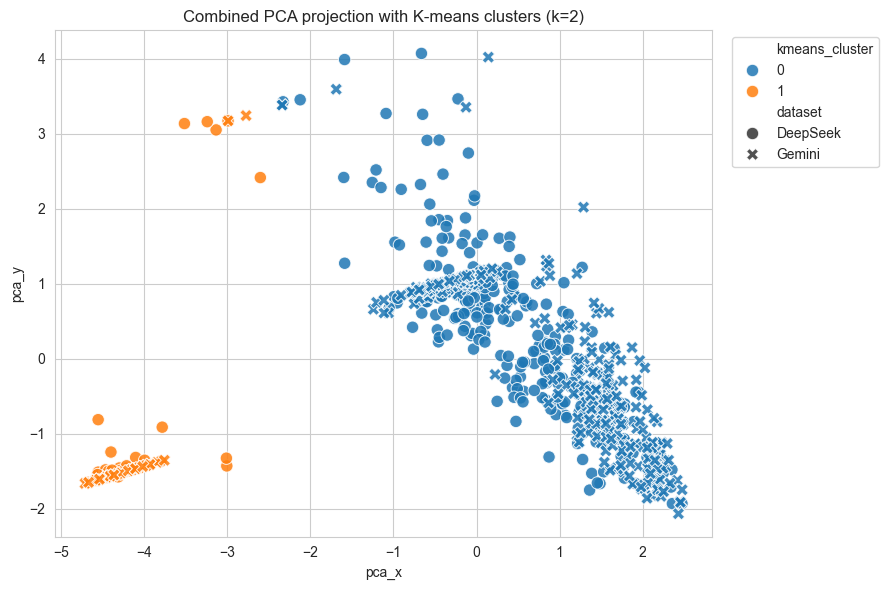

In [16]:
sns.set_style("whitegrid")

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=combined_df,
    x="pca_x", y="pca_y",
    hue="kmeans_cluster",
    style="dataset",
    palette="tab10",
    s=80, alpha=0.85
)
plt.title(f"Combined PCA projection with K-means clusters (k={k_shared})")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

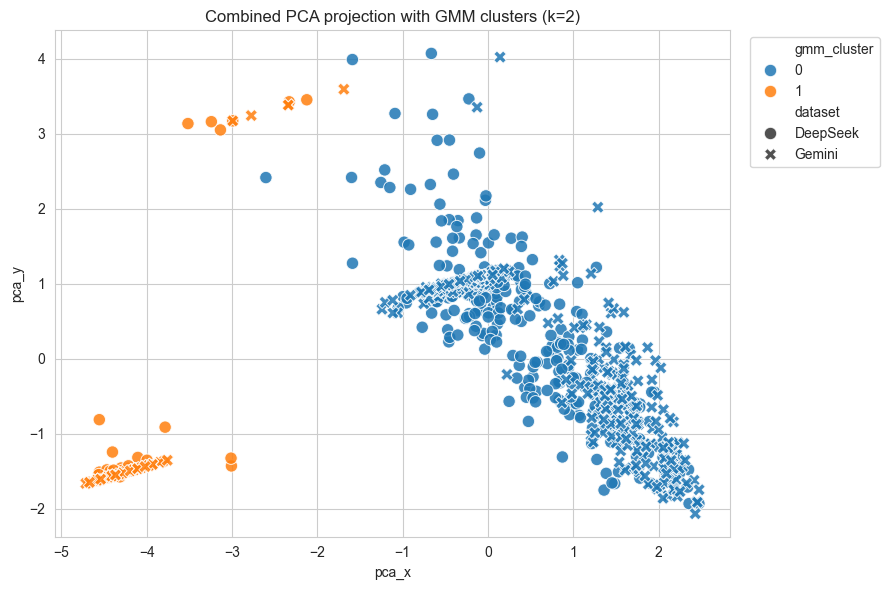

In [17]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=combined_df,
    x="pca_x", y="pca_y",
    hue="gmm_cluster",
    style="dataset",
    palette="tab10",
    s=80, alpha=0.85
)
plt.title(f"Combined PCA projection with GMM clusters (k={k_shared})")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

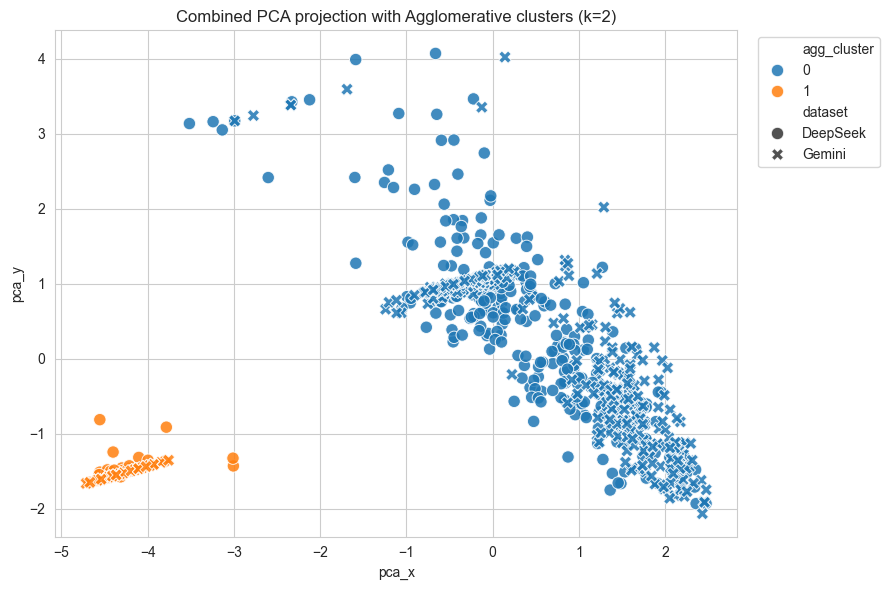

In [18]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=combined_df,
    x="pca_x", y="pca_y",
    hue="agg_cluster",
    style="dataset",
    palette="tab10",
    s=80, alpha=0.85
)
plt.title(f"Combined PCA projection with Agglomerative clusters (k={k_shared})")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Separate PCA plots for Gemini and DeepSeek with the same shared k

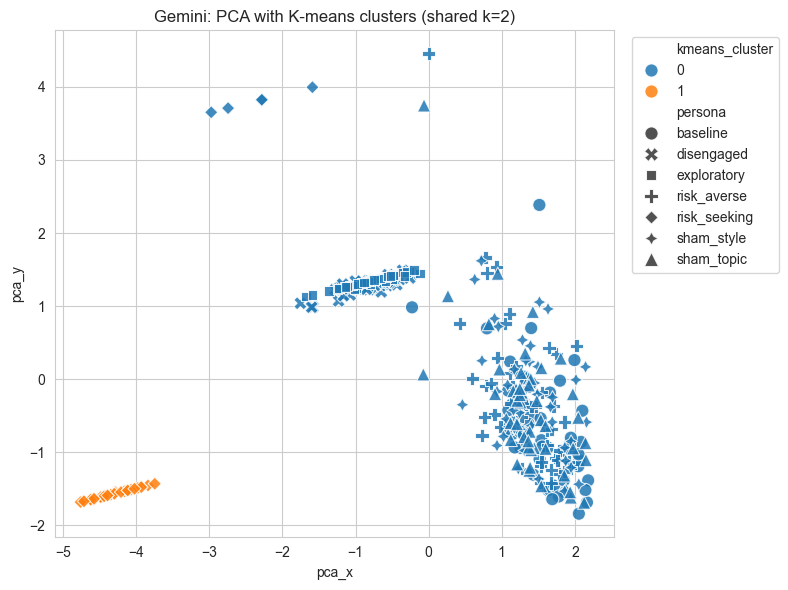

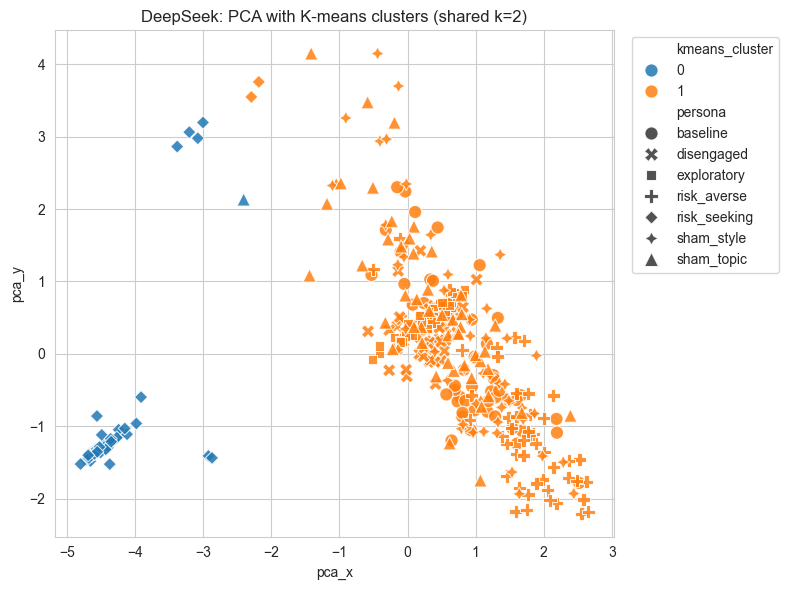

In [19]:
for dataset_name, sub in [("Gemini", gemini_df), ("DeepSeek", deepseek_df)]:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=sub,
        x="pca_x", y="pca_y",
        hue="kmeans_cluster",
        style="persona",
        palette="tab10",
        s=90, alpha=0.85
    )
    plt.title(f"{dataset_name}: PCA with K-means clusters (shared k={k_shared})")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

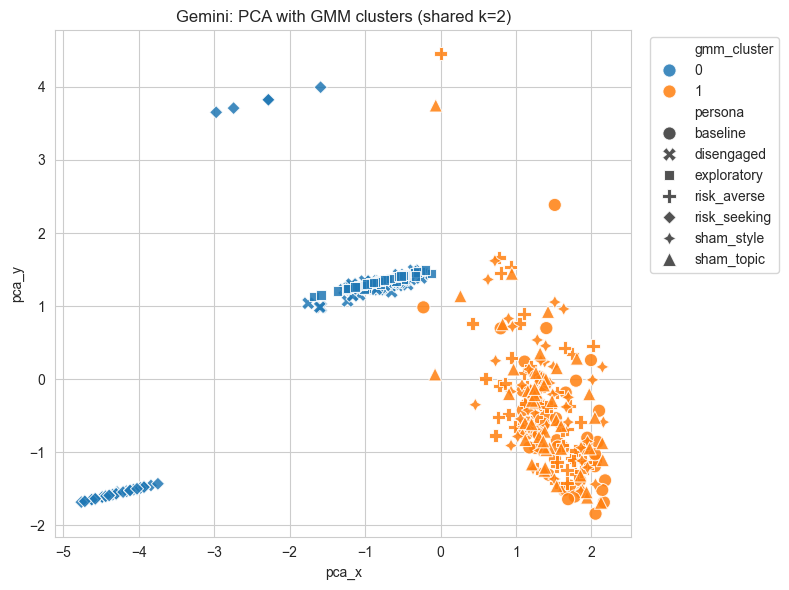

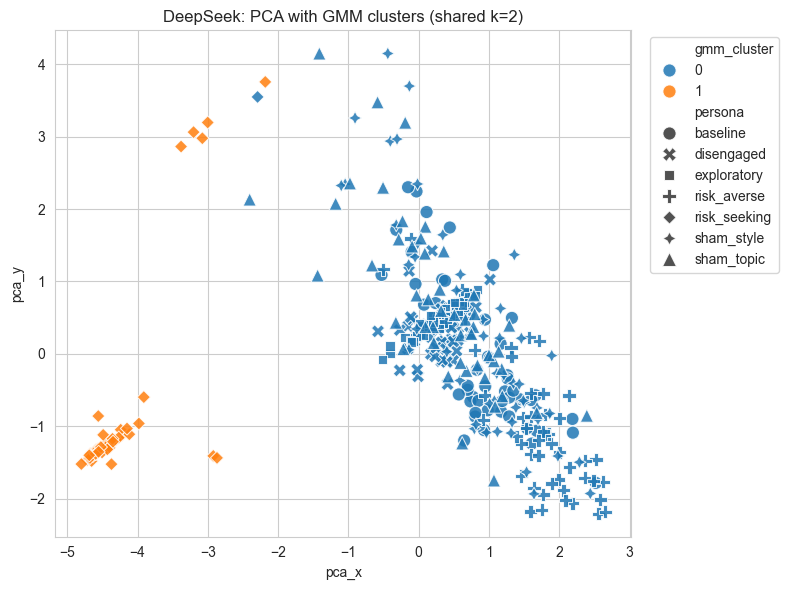

In [20]:
for dataset_name, sub in [("Gemini", gemini_df), ("DeepSeek", deepseek_df)]:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=sub,
        x="pca_x", y="pca_y",
        hue="gmm_cluster",
        style="persona",
        palette="tab10",
        s=90, alpha=0.85
    )
    plt.title(f"{dataset_name}: PCA with GMM clusters (shared k={k_shared})")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

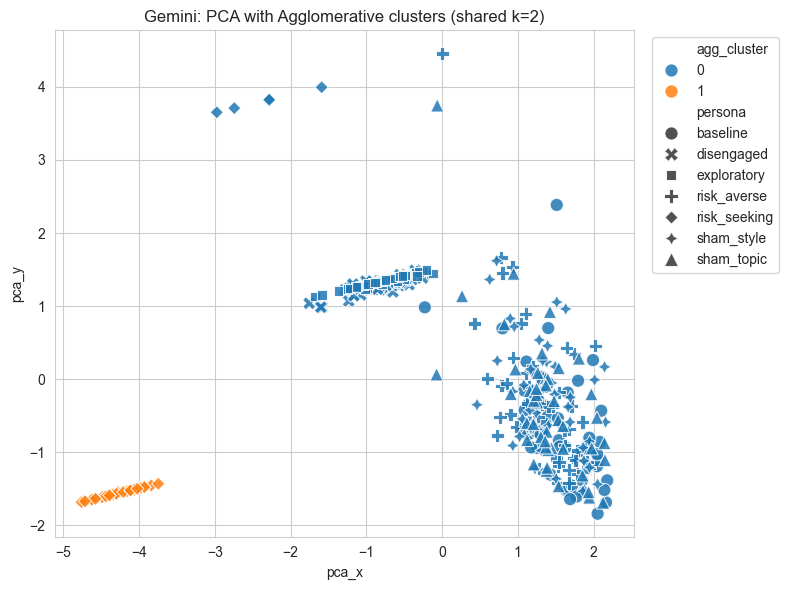

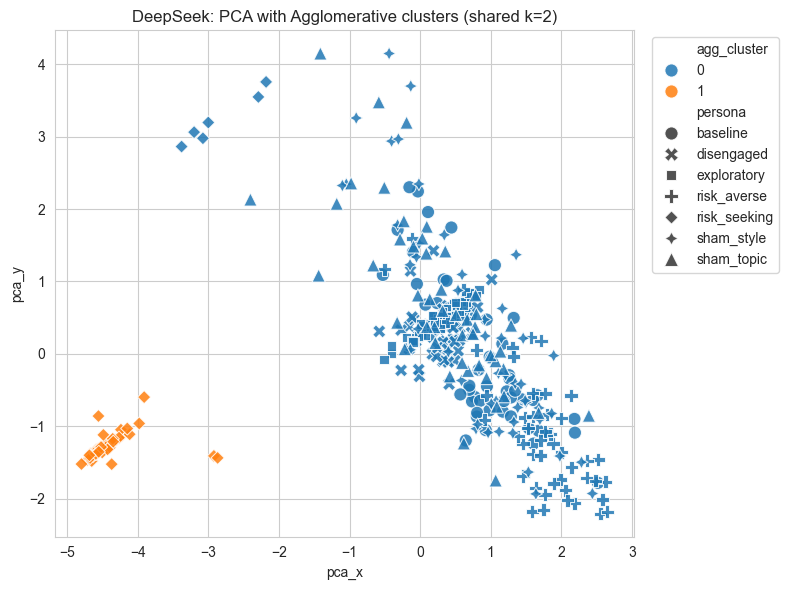

In [21]:
for dataset_name, sub in [("Gemini", gemini_df), ("DeepSeek", deepseek_df)]:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=sub,
        x="pca_x", y="pca_y",
        hue="agg_cluster",
        style="persona",
        palette="tab10",
        s=90, alpha=0.85
    )
    plt.title(f"{dataset_name}: PCA with Agglomerative clusters (shared k={k_shared})")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

### Recommendation helper

This summary table is to compare the three methods directly.

In [22]:
recommendation_df = metrics_df[[
    "silhouette_kmeans",
    "silhouette_gmm",
    "silhouette_agg",
    "ari_kmeans_vs_gmm",
    "ari_kmeans_vs_agg",
    "ari_gmm_vs_agg",
    "pca_var_2d",
    "n_sessions"
]].copy()

display(recommendation_df.round(4))

print(
    "Interpretation guide:\n"
    "- Higher silhouette is better within a dataset.\n"
    "- Higher ARI means two methods agree more.\n"
    "- If GMM and Agglomerative both disagree strongly with K-means, K-means may be forcing spherical clusters.\n"
    "- If all three methods broadly agree, the structure is more robust."
)

,silhouette_kmeans,silhouette_gmm,silhouette_agg,ari_kmeans_vs_gmm,ari_kmeans_vs_agg,ari_gmm_vs_agg,pca_var_2d,n_sessions
Gemini,0.5309,0.4050,0.5309,0.1493,1.0000,0.1493,0.6835,350
DeepSeek,0.5070,0.5080,0.5082,0.9689,0.9205,0.9205,0.6258,350
Combined,0.5104,0.5105,0.5096,0.9535,0.9440,0.9136,0.6417,700


Interpretation guide:
- Higher silhouette is better within a dataset.
- Higher ARI means two methods agree more.
- If GMM and Agglomerative both disagree strongly with K-means, K-means may be forcing spherical clusters.
- If all three methods broadly agree, the structure is more robust.


In [23]:
combined_df.groupby("kmeans_cluster")[feature_cols].mean()

,deck_Q_pct,deck_K_pct,deck_S_pct,net_score,learning_slope,risk_seeking,loss_sensitivity,final_total
kmeans_cluster,,,,,,,,
0,0.110298,0.227914,0.347897,0.323576,0.126490,0.338212,0.575770,2733.940397
1,0.921042,0.072604,0.006354,-0.987292,-0.007708,0.993646,0.020753,-495.833333


**Cluster 0 (n = 604 / 700): Non-risk-seeking cluster**

* **Deck usage:** Mixed choices but has a clear tilt toward advantageous decks (S and D).
* **Net score:** Positive (~0.32), showing advantageous selections outweighing disadvantageous ones.
* **Learning slope:** Positive (~0.12), indicating a shift toward good decks in later trials vs earlier trials.
* **Risk-seeking:** Moderate/Low (~0.33), showing they do not hyperfixate on high-reward/high-penalty decks.
* **Loss sensitivity:** Moderate (~0.57), indicating they frequently switch strategies after encountering a loss.
* **Final total:** High positive (~2733).

**Interpretation:** This cluster represents a non-risk seeking cluster, learning-capable decision-making. Agents in this group explore the decks, respond appropriately to negative feedback (loss sensitivity), and shift their strategy toward safer, positive-expected-value decks over time, resulting in a healthy final profit.

**Cluster 1 (n = 96 / 700): Risk-seeking cluster**

* **Deck usage:** Highly concentrated on high-upfront-reward decks (approx. 92% Deck Q and 7% Deck K).
* **Net score:** Strongly negative (-0.98), showing almost exclusively disadvantageous selections.
* **Learning slope:** Flat/Negative (-0.007), showing no improvement or adaptation across the session.
* **Risk-seeking:** Extremely high (~0.99), indicating an overwhelming preference for high-reward/high-variance decks.
* **Loss sensitivity:** Near zero (~0.02), indicating they almost never switch decks after a loss.
* **Final total:** Negative (-495).

**Interpretation:** Agents in this cluster exhibit an extreme, risk-seeking behaviou and is driven entirely by immediate high rewards. They hyper-fixate on disadvantageous decks and completely fail to respond to negative feedback. This impulsive, perseverative behavior results in a net loss for the session.

In [24]:
pd.crosstab(combined_df["dataset"], combined_df["kmeans_cluster"])

kmeans_cluster,0,1
dataset,,
DeepSeek,301,49
Gemini,303,47


### **Interpretation**

Both datasets split into the same two behavioural regimes with almost identical counts:

**Cluster 0 (Non-risk-seeking cluster):**
* DeepSeek: 301/350 ≈ 86%
* Gemini: 303/350 ≈ 86.5%

**Cluster 1 (Risk-seeking cluster):**
* DeepSeek: 49/350 ≈ 14%
* Gemini: 47/350 ≈ 13.5%

In [25]:
sil_vals = silhouette_samples(X_combined_scaled, combined_df["kmeans_cluster"])
combined_df["silhouette"] = sil_vals

cluster_sil = combined_df.groupby("kmeans_cluster")["silhouette"].mean()
print(cluster_sil)

kmeans_cluster
0    0.476101
1    0.726465
Name: silhouette, dtype: float64


In [26]:
print("K-means:", silhouette_score(X_combined_scaled, combined_df["kmeans_cluster"]))
print("GMM:", silhouette_score(X_combined_scaled, combined_df["gmm_cluster"]))
print("Agglomerative:", silhouette_score(X_combined_scaled, combined_df["agg_cluster"]))

K-means: 0.510436527656463
GMM: 0.5104682060797895
Agglomerative: 0.509602369039147


### **Interpretation**

The silhouette score measures how well-separated and cohesive the clusters are, with higher values indicating better-defined clusters.

* K-means (~0.51): Clear, stable separation
* Agglomerative (~0.51): Same structure as K-means
* GMM (~0.51): Converges to the same partition

#### **Overall insight**
The behavioural space supports a moderately strong, highly robust 2-cluster structure. All three algorithms agree perfectly and give the same silhouette score (~0.51), showing an extremely stable segmentation which is not an artefact of the algorithm, but a true and dominant behavioral divergence.

### 

## More on persona distribution by cluster

This is to interpret whether the personas align with clusters in K-means (clusters are more robust and seperated in Kmeans)

In [27]:
for name, df in [("Combined", combined_df), ("Gemini", gemini_df), ("DeepSeek", deepseek_df)]:
    X = df[feature_cols]
    X_scaled = StandardScaler().fit_transform(X)
    
    score = silhouette_score(X_scaled, df["kmeans_cluster"])
    print(f"{name} silhouette:", round(score, 3))
    
    ct = pd.crosstab(
        df["persona"],
        df["kmeans_cluster"],
        normalize="index"
    ) * 100
    
    display(ct.round(1))

Combined silhouette: 0.51


kmeans_cluster,0,1
persona,,
baseline,100.0,0.0
disengaged,100.0,0.0
exploratory,100.0,0.0
risk_averse,100.0,0.0
risk_seeking,5.0,95.0
sham_style,100.0,0.0
sham_topic,99.0,1.0


Gemini silhouette: 0.531


kmeans_cluster,0,1
persona,,
baseline,100.0,0.0
disengaged,100.0,0.0
exploratory,100.0,0.0
risk_averse,100.0,0.0
risk_seeking,10.0,90.0
sham_style,100.0,0.0
sham_topic,100.0,0.0


DeepSeek silhouette: 0.507


kmeans_cluster,0,1
persona,,
baseline,0.0,100.0
disengaged,0.0,100.0
exploratory,0.0,100.0
risk_averse,0.0,100.0
risk_seeking,96.0,4.0
sham_style,0.0,100.0
sham_topic,2.0,98.0


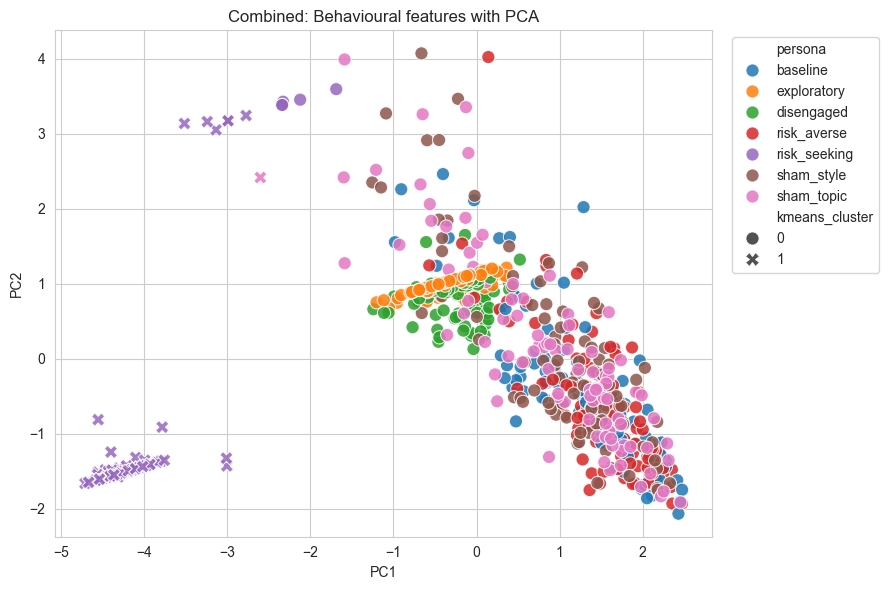

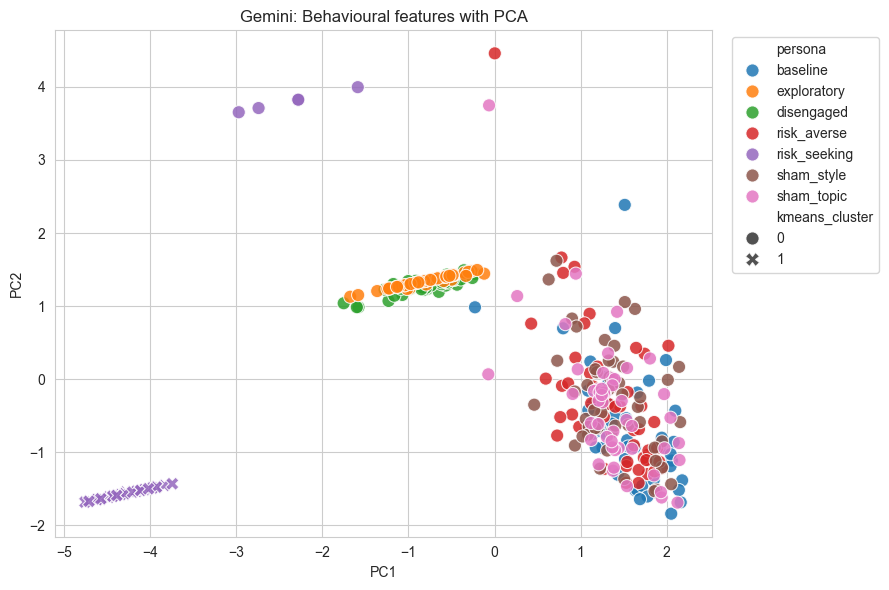

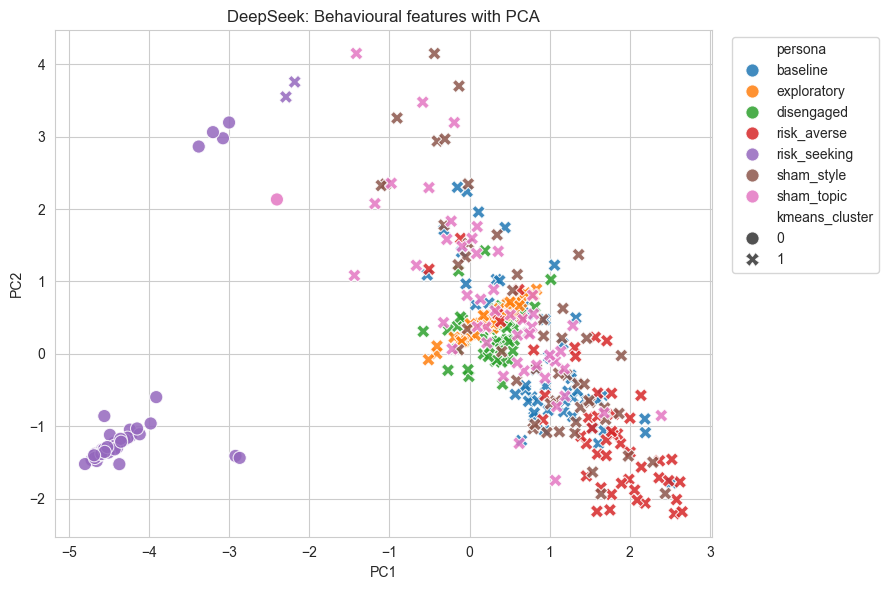

In [28]:
persona_order = [
    "baseline", "exploratory", "disengaged", "risk_averse",
    "risk_seeking", "sham_style", "sham_topic"
]

def plot_clusters_pca(df, feature_cols, title):
    X = df[feature_cols].copy()
    X_scaled = StandardScaler().fit_transform(X)

    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X_scaled)

    plot_df = df.copy()
    plot_df["PC1"] = coords[:, 0]
    plot_df["PC2"] = coords[:, 1]

    var = pca.explained_variance_ratio_.sum()

    # colour palette
    palette = sns.color_palette("tab10", n_colors=len(persona_order))
    persona_colors = {p: palette[i] for i, p in enumerate(persona_order)}

    plt.figure(figsize=(9,6))
    ax = sns.scatterplot(
        data=plot_df,
        x="PC1", y="PC2",
        hue="persona",
        hue_order=persona_order,
        palette=persona_colors,
        style="kmeans_cluster",    # cluster shown by marker shape
        s=90, alpha=0.85
    )

    plt.title(f"{title}: Behavioural features with PCA")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_clusters_pca(combined_df, feature_cols, "Combined")
plot_clusters_pca(gemini_df, feature_cols, "Gemini")
plot_clusters_pca(deepseek_df, feature_cols, "DeepSeek")

### Chi-square test and Cramér’s V

We run chi-square test to see how many of each persona ended up in the clusters. This tests the null hypothesis that "the prompt a model receives has no effect on which cluster it ends up in"

* p < 0.05 → personas do affect behaviour
* p > 0.05 → personas don’t matter much

Chi-Square only tests if there is an effect. So we use Cramer's V to measure how strong that effect is on a scale from 0 to 1.

* Cramer's V < 0.5 → weak effect
* Cramer's V > 0.5 → strong effect

In [29]:
for name, df in [("Combined", combined_df), ("Gemini", gemini_df), ("DeepSeek", deepseek_df)]:
    print("\n", name)
    
    ct = pd.crosstab(df["persona"], df["kmeans_cluster"])
    
    chi2, p, _, _ = chi2_contingency(ct)
    
    n = ct.values.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

    print("Chi-square:", chi2)
    print("p-value:", p)
    print("Cramér’s V:", round(cramers_v, 3))


 Combined
Chi-square: 651.4935154525388
p-value: 1.8087446825845115e-137
Cramér’s V: 0.965

 Gemini
Chi-square: 309.8360655737705
p-value: 6.37872347180668e-64
Cramér’s V: 0.941

 DeepSeek
Chi-square: 325.9136212624585
p-value: 2.276152925845238e-67
Cramér’s V: 0.965


### **Persona Interpretation**

**Combined dataset**

* Chi-square: 651.49
* p-value: ~1.81e-137 (≈ 0)
* Cramér’s V: 0.965

Interpretation: There is a significant association between persona and cluster membership in the combined data, and the effect size is exceptionally large (V = 0.965). This confirms that, overall, the prompt-engineered personas map almost perfectly onto the two behavioural clusters.

**Gemini**

* Chi-square: 309.84
* p-value: ~6.38e-64 (≈ 0)
* Cramér’s V: 0.941

Interpretation: Within Gemini, cluster membership is heavily dependent on persona. The association is not only statistically significant but also very strong (V = 0.941).

**DeepSeek**

* Chi-square: 325.91
* p-value: ~2.28e-67 (≈ 0)
* Cramér’s V: 0.965

Interpretation: DeepSeek shows the exact same pattern: persona and cluster membership are tightly linked, with an extremely large effect size (V = 0.965).

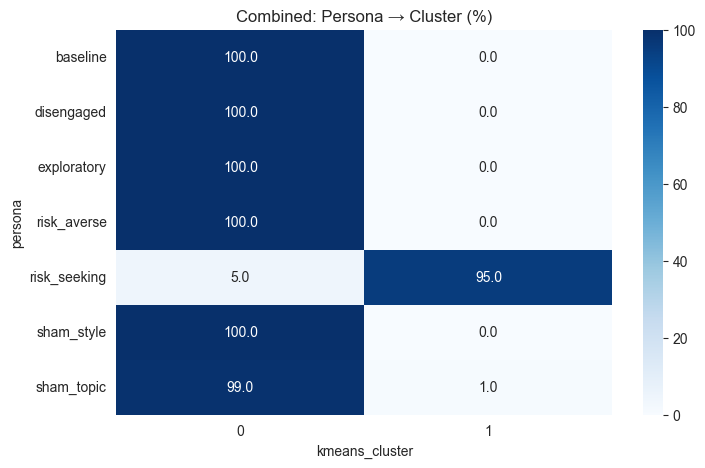

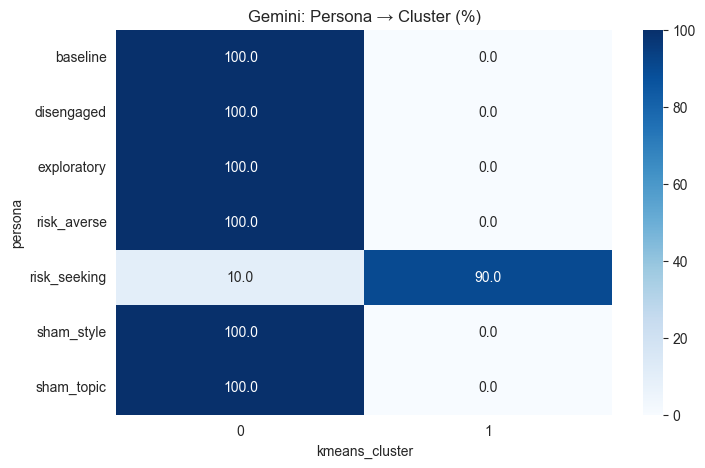

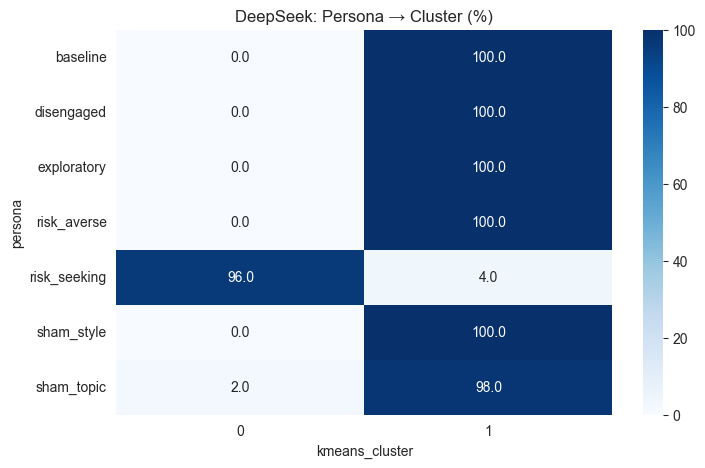

In [30]:
for name, df in [("Combined", combined_df), ("Gemini", gemini_df), ("DeepSeek", deepseek_df)]:
    ct = pd.crosstab(
        df["persona"],
        df["kmeans_cluster"],
        normalize="index"
    ) * 100

    plt.figure(figsize=(8,5))
    sns.heatmap(ct, annot=True, fmt=".1f", cmap="Blues")
    plt.title(f"{name}: Persona → Cluster (%)")
    plt.show()